# Multivariate player profiling and win prediction in CS:GO: analysis walkthrough

This notebook reproduces the key results of the project from the processed data. It imports the project's own modules from `src/`, so the numbers here are the same ones used in the README and the dashboard. To rebuild the processed data from the raw Kaggle files, see the README.

**Pipeline:** KPI matrix X (n x 6) -> EDA -> PCA -> K-Means archetypes -> team-level MANOVA (paired Wilks' Lambda) -> win model.

In [1]:
import sys, warnings
from pathlib import Path
import numpy as np, pandas as pd
from IPython.display import Image, display
warnings.filterwarnings("ignore")
pd.set_option("display.width", 160)

ROOT = Path.cwd()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))
FIG, TAB, PROC = ROOT / "outputs" / "figures", ROOT / "outputs" / "tables", ROOT / "data" / "processed"

KPIS = ["kd", "hs_pct", "adr", "opening_rate", "utility_pr", "loadout_value"]
kpi = pd.read_csv(PROC / "player_match_kpis.csv")
print(f"n = {len(kpi):,} player-match rows, {kpi.file.nunique():,} matches")
kpi[["file", "player_id", "team", "rounds_played", *KPIS, "team_won"]].head()

n = 12,767 player-match rows, 1,289 matches


,file,player_id,team,rounds_played,kd,hs_pct,adr,opening_rate,utility_pr,loadout_value,team_won
0,003201673717864202280_0171883906.dem,P10290,Team 2,30.0,0.760000,0.473684,76.400000,0.033333,1.600000,1361.076703,0.0
1,003201673717864202280_0171883906.dem,P05292,Team 1,30.0,0.909091,0.450000,76.400000,0.033333,2.000000,2591.309468,1.0
2,003201673717864202280_0171883906.dem,P08443,Team 1,30.0,1.052632,0.350000,74.500000,0.066667,0.733333,1630.461330,1.0
3,003201673717864202280_0171883906.dem,P08152,Team 1,30.0,1.210526,0.565217,78.366667,0.200000,0.266667,3637.396784,1.0
4,003201673717864202280_0171883906.dem,P05913,Team 1,29.0,1.590909,0.571429,127.965517,0.241379,0.310345,2399.447588,1.0


## 1. Exploratory analysis: mean vector, covariance, correlation

The data matrix is X in R^(n x p) with p = 6. Sample mean vector x-bar and covariance S:

In [2]:
X = kpi[KPIS]
summary = pd.DataFrame({"mean (x-bar)": X.mean(), "sd": X.std(), "skew": X.skew()})
display(summary.round(3))
display(X.cov().round(3))

,mean (x-bar),sd,skew
kd,1.073,0.618,3.557
hs_pct,0.362,0.152,0.306
adr,79.332,23.160,0.564
opening_rate,0.102,0.076,1.003
utility_pr,1.043,0.615,0.503
loadout_value,2285.779,468.756,0.382


,kd,hs_pct,adr,opening_rate,utility_pr,loadout_value
kd,0.381,0.001,10.307,0.018,0.092,88.773
hs_pct,0.001,0.023,0.269,0.000,0.006,-18.496
adr,10.307,0.269,536.364,0.926,3.001,2477.152
opening_rate,0.018,0.000,0.926,0.006,0.002,8.418
utility_pr,0.092,0.006,3.001,0.002,0.379,-18.184
loadout_value,88.773,-18.496,2477.152,8.418,-18.184,219732.247


In [3]:
from eda import sigma_diagnostics
diag = sigma_diagnostics(X.cov().to_numpy(), X.corr().to_numpy())
pd.Series(diag, name="value")

positive_definite (Cholesky succeeds)          True
det(S)                                   590.279506
det(R)                                     0.258146
min eigenvalue of R                        0.247305
max eigenvalue of R                        2.299908
condition number of R                      9.299889
rank(S)                                           6
Name: value, dtype: object

The sample covariance is positive definite (rank 6, condition number of R about 9), so PCA and the covariance-based tests are well defined. K/D is strongly right-skewed (skew 3.6).

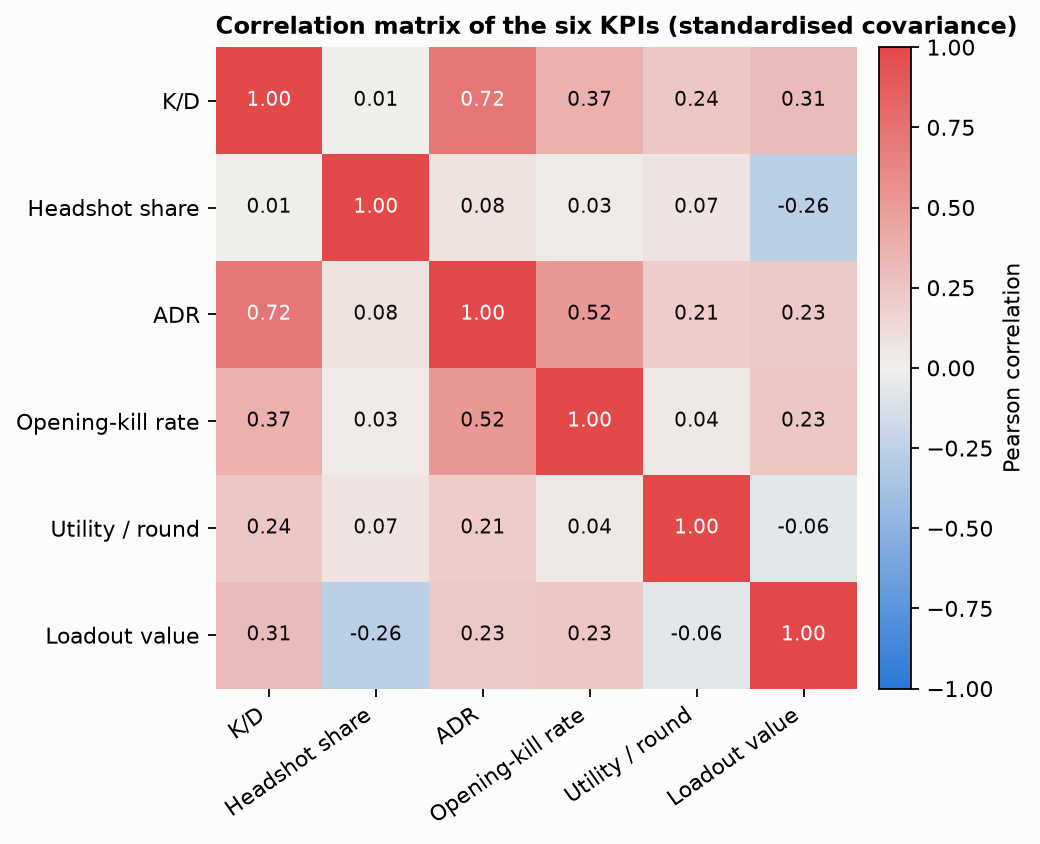

In [4]:
display(Image(FIG / 'correlation_heatmap.png', width=520))

## 2. PCA

In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
Z = StandardScaler().fit_transform(X)
pca = PCA().fit(Z)
names = [f"PC{i}" for i in range(1, 7)]
display(pd.DataFrame({"eigenvalue": pca.explained_variance_, "variance": pca.explained_variance_ratio_,
                      "cumulative": pca.explained_variance_ratio_.cumsum()}, index=names).round(3))
display(pd.DataFrame(pca.components_.T * np.sqrt(pca.explained_variance_), index=KPIS, columns=names).round(2))

,eigenvalue,variance,cumulative
PC1,2.300,0.383,0.383
PC2,1.281,0.214,0.597
PC3,0.946,0.158,0.754
PC4,0.647,0.108,0.862
PC5,0.579,0.096,0.959
PC6,0.247,0.041,1.000


,PC1,PC2,PC3,PC4,PC5,PC6
kd,0.85,0.07,0.10,0.16,-0.36,-0.32
hs_pct,-0.01,0.76,-0.47,0.41,0.18,-0.01
adr,0.88,0.15,-0.08,-0.05,-0.24,0.36
opening_rate,0.69,-0.04,-0.38,-0.46,0.39,-0.11
utility_pr,0.30,0.49,0.75,-0.02,0.31,0.01
loadout_value,0.47,-0.65,0.04,0.49,0.33,0.05


Three components are retained (75.4% of variance). PC1 is aggression / impact, PC2 contrasts precision (headshot share) with weapon tier (loadout value), and PC3 is utility / support.

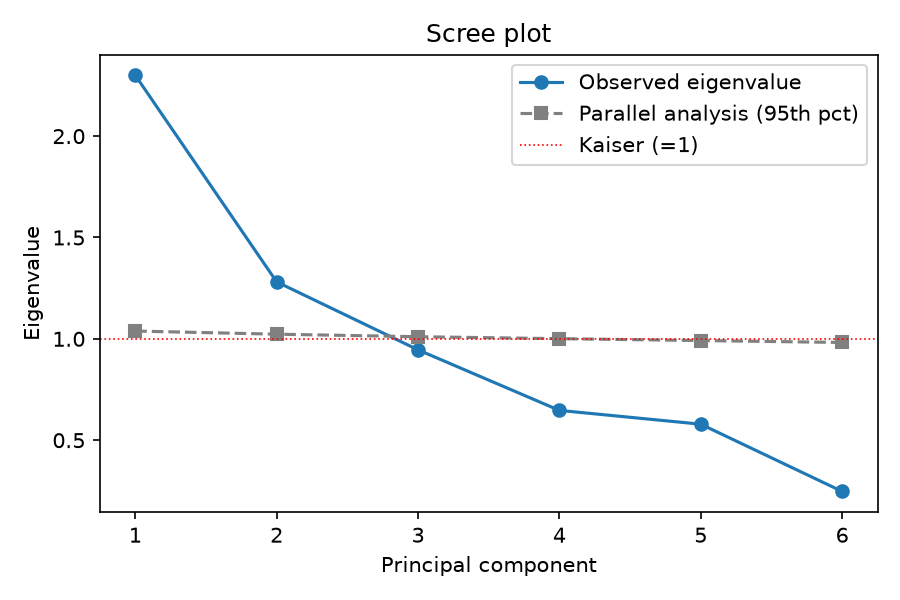

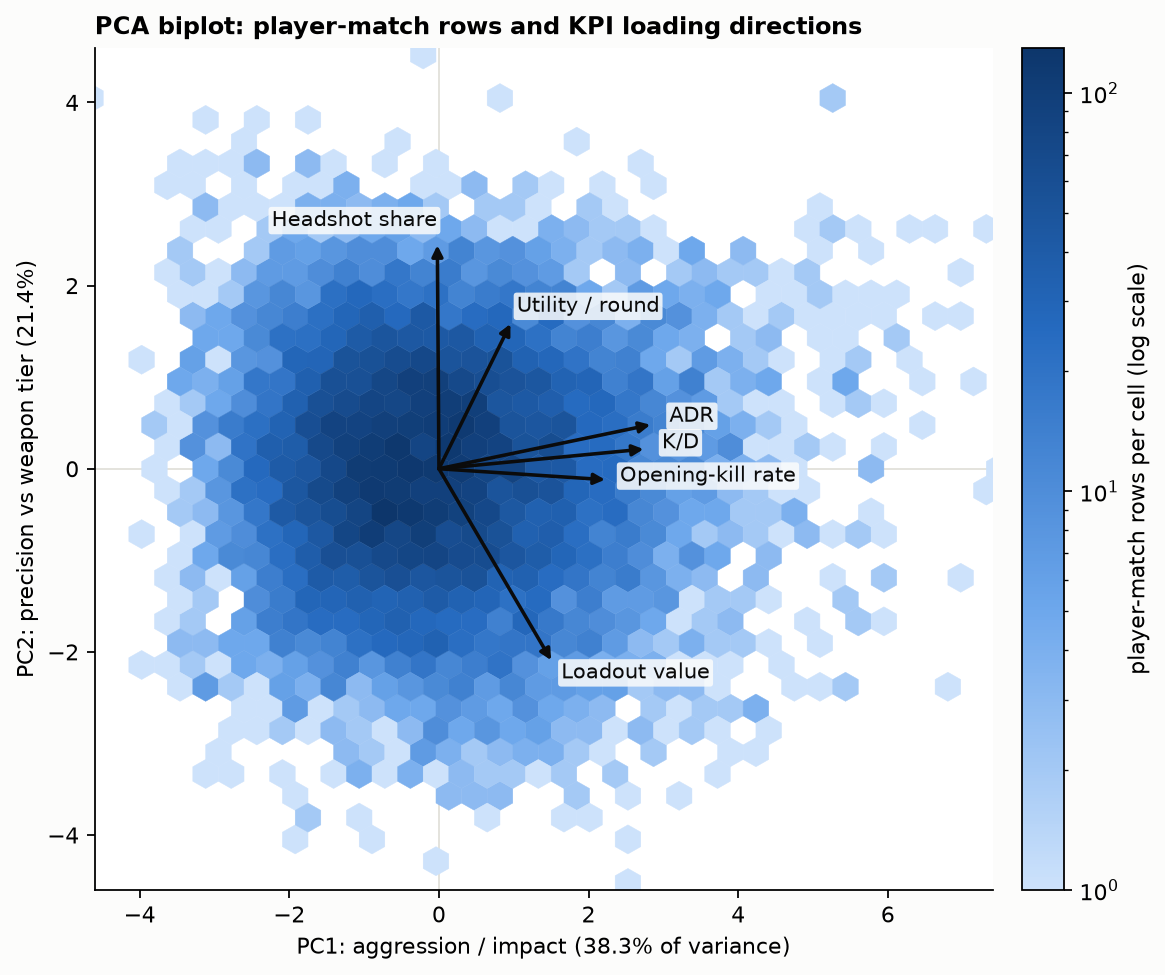

In [6]:
display(Image(FIG / 'scree_plot.png', width=460)); display(Image(FIG / 'pca_biplot.png', width=560))

## 3. K-Means archetypes (k = 4)

In [7]:
labels = pd.read_csv(PROC / "cluster_labels_k4.csv")
df = kpi.merge(labels[["file", "player_id", "archetype"]], on=["file", "player_id"])
prof = df.groupby("archetype")[KPIS].mean().round(2)
prof.insert(0, "share", (df.archetype.value_counts(normalize=True)).round(3))
prof.sort_values("kd", ascending=False)

,share,kd,hs_pct,adr,opening_rate,utility_pr,loadout_value
archetype,,,,,,,
Star Fragger,0.184,1.84,0.37,109.86,0.20,1.09,2588.76
Utility Support,0.242,1.18,0.37,84.30,0.09,1.71,2203.75
Heavy-Weapon Anchor,0.295,0.85,0.24,68.87,0.08,0.69,2503.46
Budget Headshotter,0.279,0.71,0.48,65.94,0.07,0.81,1927.08


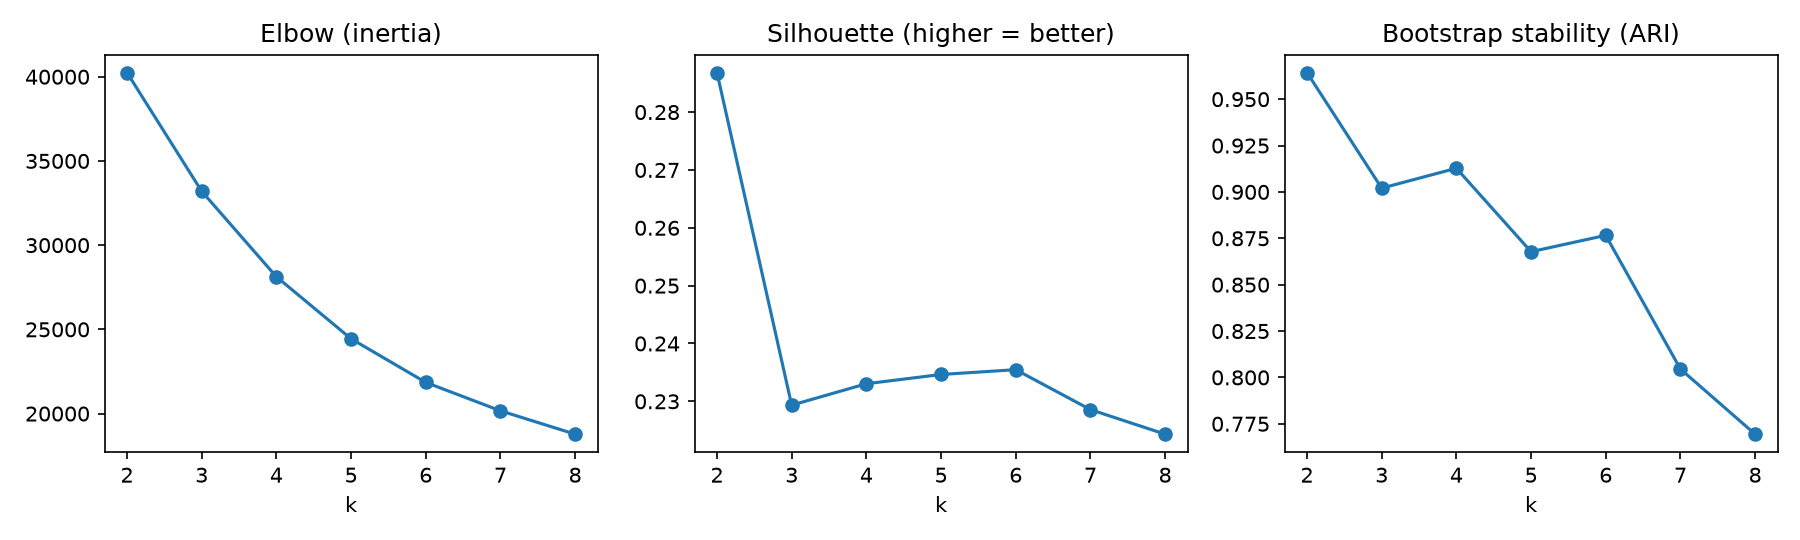

In [8]:
display(Image(FIG / 'kmeans_k_selection.png', width=760))

The silhouette is only about 0.23 at every k, so the archetypes are a descriptive segmentation of a continuum rather than naturally separated clusters.

## 4. MANOVA (Wilks' Lambda): assumptions first

In [9]:
import manova
t = manova.team_table()
y, Xt = t.team_won.to_numpy(), t[KPIS].to_numpy()
print(f"{len(t)} team-matches: {int((y == 1).sum())} winners, {int((y == 0).sum())} losers (ties excluded)")
for name, v in (("winners", 1.0), ("losers", 0.0)):
    b1, sp, b2, z, kp = manova.mardia(Xt[y == v])
    print(f"Mardia {name}: skew b1={b1:.2f} (p={sp:.2g}), kurtosis b2={b2:.1f} vs expected 48 (p={kp:.2g})")
M, chi2, dof, p = manova.box_m([Xt[y == 1], Xt[y == 0]])
print(f"Box's M = {M:.1f}, chi2 = {chi2:.1f}, df = {dof:.0f}, p = {p:.3g}")

2330 team-matches: 1165 winners, 1165 losers (ties excluded)
Mardia winners: skew b1=25.35 (p=0), kurtosis b2=106.8 vs expected 48 (p=0)
Mardia losers: skew b1=9.17 (p=0), kurtosis b2=83.9 vs expected 48 (p=0)
Box's M = 2401.7, chi2 = 2395.1, df = 21, p = 0


Both multivariate normality and equal covariances are rejected, and the winner and loser rows come from the same match (dependent). So the primary test is a **paired within-match** Hotelling T2 / Wilks' Lambda with a sign-flip permutation p-value.

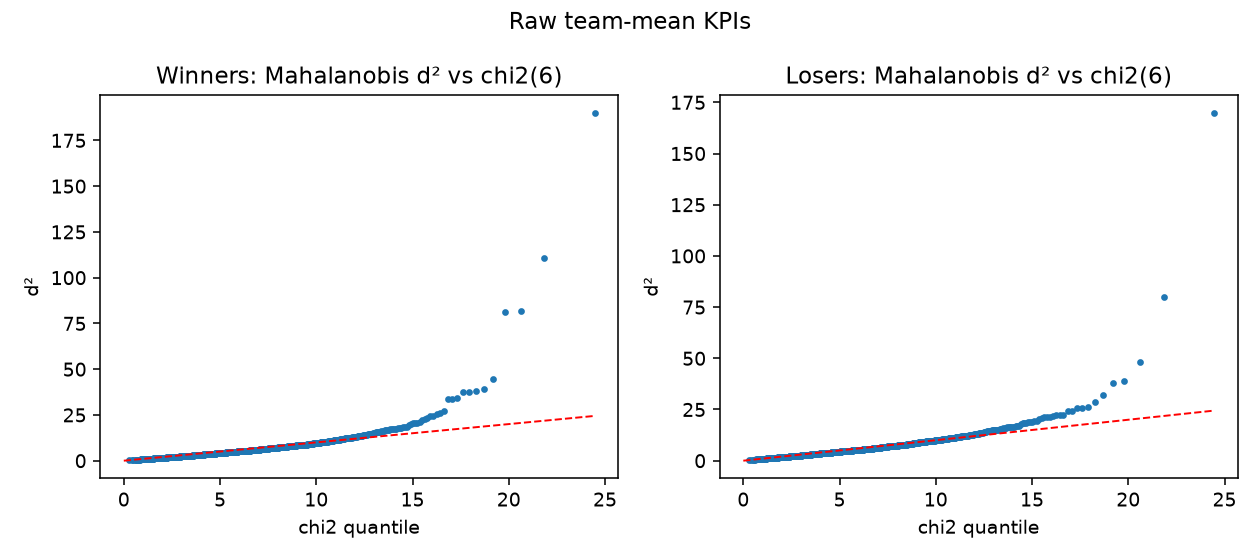

In [10]:
display(Image(FIG / 'mvn_qq_raw.png', width=680))

In [11]:
lam = manova.paired_manova(t)
manova.twogroup_manova(t)


=== PRIMARY: paired within-match MANOVA (Wilks' Lambda) ===
pairs n=1165, p=6; Hotelling T2=1441.3; Wilks' Lambda=0.4468; F(6,1159)=239.2; asymptotic F p=8.72e-199 (not reliable: normality fails; use the permutation p)
sign-flip permutation p (B=20000) = 5e-05  (smallest possible 5e-05); max permuted T2 = 32.6
effect size: partial eta^2 = 1 - Lambda = 0.553

Per-KPI follow-up (Bonferroni over 6 KPIs) and standardised discriminant weights:
               mean_diff   sd_diff  cohens_dz        t  p_bonf  std_discriminant_weight
kd                0.5419    0.5211     1.0398  35.4907  0.0000                   0.4067
hs_pct           -0.0093    0.1000    -0.0927  -3.1642  0.0096                   0.0375
adr              11.7571   12.2342     0.9610  32.8011  0.0000                   0.1090
opening_rate      0.0291    0.0455     0.6404  21.8583  0.0000                   0.0517
utility_pr        0.2391    0.4078     0.5864  20.0135  0.0000                   0.1474
loadout_value   243.2181  32

## 5. Bivariate normal density of the archetypes

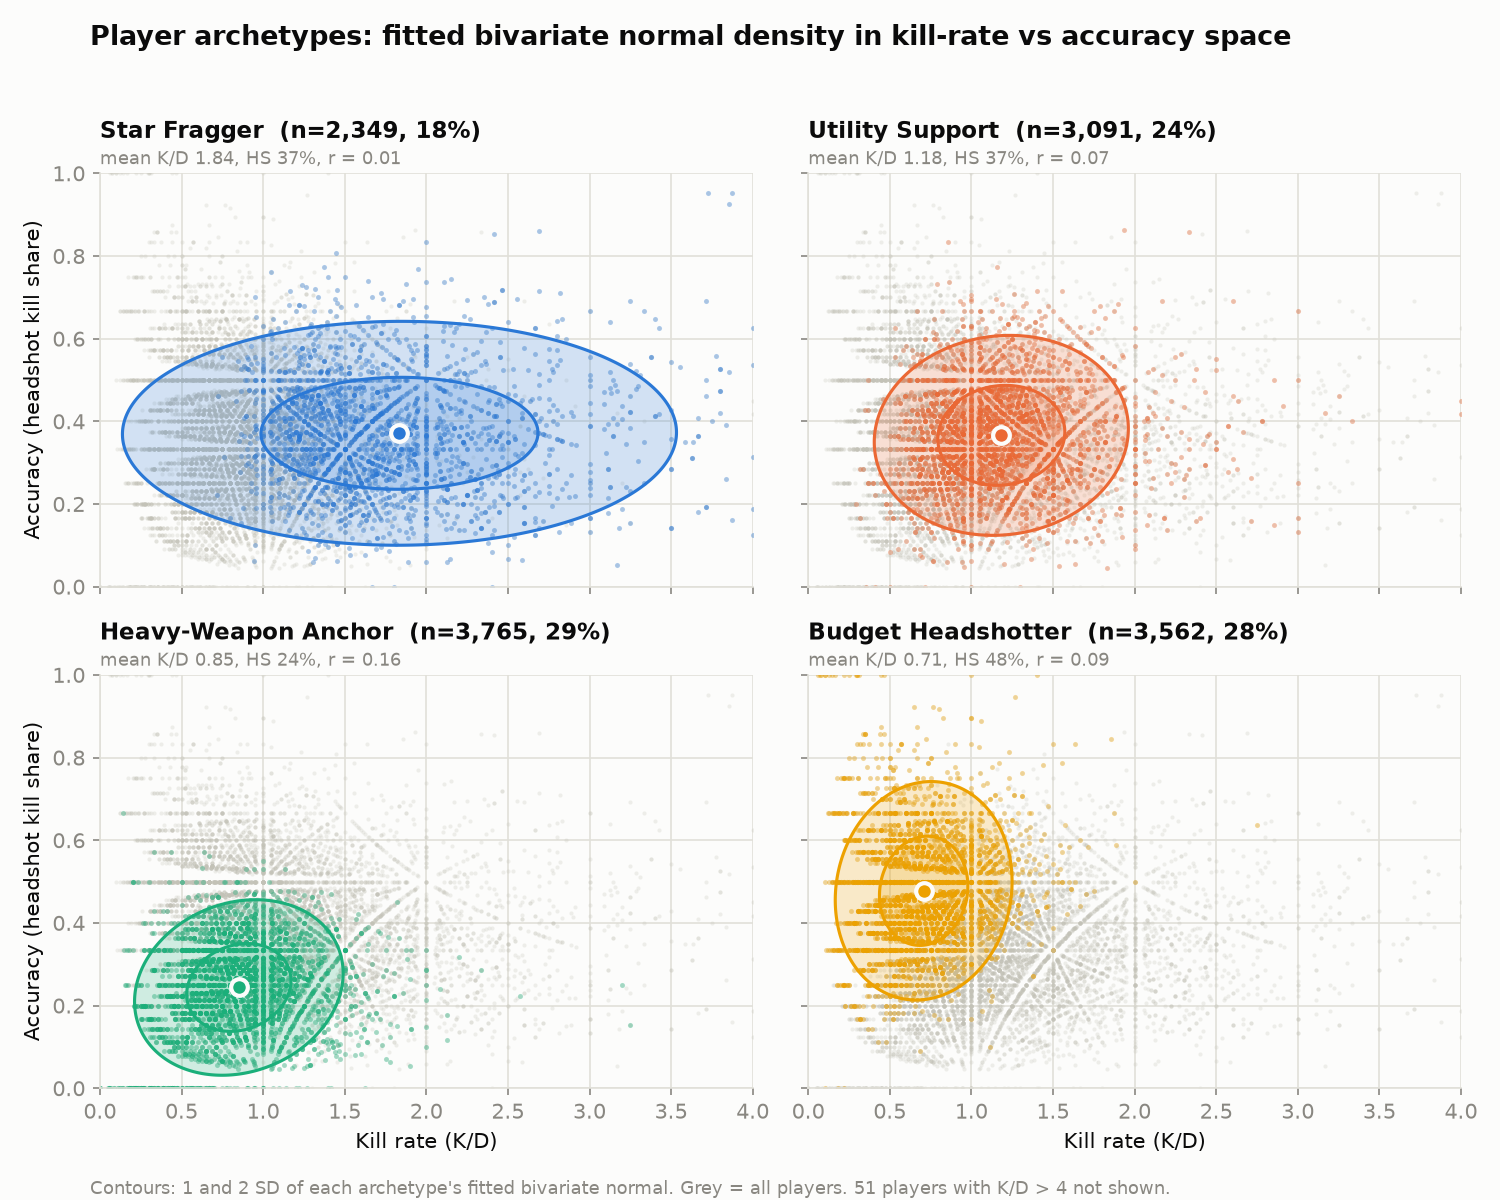

In [12]:
display(Image(FIG / 'archetype_bivariate_density.png', width=720))

## 6. Win probability and team balance

In [13]:
import model
art = model.load()
m = art["metrics"]
print(f"Logistic on 6 team-mean KPIs, match-grouped 5-fold CV: AUC={m['auc']:.3f}, accuracy={m['accuracy']:.3f}, Brier={m['brier']:.3f}")
example = kpi[(kpi.team_won == 1) & (kpi.team_size == 5)].iloc[5]
team = kpi[(kpi.file == example.file) & (kpi.team == example.team)]
res = model.score_team(art, team[KPIS])
print("archetypes:", list(res["archetypes"]))
print(f"balance = {res['balance']:.2f}, P(win) = {res['win_probability']:.3f}")

Logistic on 6 team-mean KPIs, match-grouped 5-fold CV: AUC=0.979, accuracy=0.926, Brier=0.056
archetypes: ['Budget Headshotter', 'Budget Headshotter', 'Star Fragger', 'Heavy-Weapon Anchor', 'Utility Support']
balance = 0.96, P(win) = 1.000


## Reading the results

* Winning teams differ from losing teams on the joint KPI vector (paired Wilks' Lambda about 0.45, partial eta-squared about 0.55, permutation p < 0.0001), but the relationship is close to mechanical: rounds are won by eliminations, and K/D alone classifies winners almost as well (AUC 0.977 vs 0.979).
* The archetypes are useful descriptive segments (Star Fragger, Utility Support, Heavy-Weapon Anchor, Budget Headshotter), not sharply separated groups.
* The win probability means "how likely a team with this KPI profile is a winning team" and is not a pre-match forecast.